# Part 2: Hive Queries
### Banking Dataset Analysis
> Hive queries are simulated using **pandasql** in Google Colab (same SQL syntax as HiveQL). This approach produces identical results without needing a Hive server.
### Github : xxxxxxxx

In [ ]:
!pip install pandasql matplotlib seaborn -q
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import pandasql as ps
print('Ready to go ✓')

Ready to go ✓


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/SPECIALIZATION MS PROJECTS/MODULE 2/bank.csv')
df.rename(columns={'default':'default_credit'}, inplace=True)
client_info = df  # table alias for SQL
print(f'Loaded {len(df)} rows')
df.head(3)

Mounted at /content/drive
Loaded 4521 rows


,age,job,marital,education,default_credit,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no


## Q1 – Data Ingestion and Table Creation
```sql
CREATE DATABASE banking_data;
CREATE TABLE client_info (age INT, job STRING, ...);
LOAD DATA INPATH '/user/hive/bank.csv' INTO TABLE client_info;
```

In [ ]:
# Simulate database and table schema display using pandas
print('Database: banking_data')
print('Table: client_info')
print('Schema:')

for column_name, data_type in df.dtypes.items():
    print(f'  {column_name}: {data_type}')

Database: banking_data
Table: client_info
Schema:
  age: int64
  job: object
  marital: object
  education: object
  default_credit: object
  balance: int64
  housing: object
  loan: object
  contact: object
  day: int64
  month: object
  duration: int64
  campaign: int64
  pdays: int64
  previous: int64
  poutcome: object
  y: object


## Q2 – Basic Data Exploration

In [ ]:
# Query: total number of clients
query = 'SELECT COUNT(*) AS total_clients FROM client_info'
total_clients_df = ps.sqldf(query, locals())
print(total_clients_df)

# Display first 10 records from the table
print(client_info.head(10).to_string(index=False))

   total_clients
0           4521
 age           job marital education default_credit  balance housing loan  contact  day month  duration  campaign  pdays  previous poutcome  y
  30    unemployed married   primary             no     1787      no   no cellular   19   oct        79         1     -1         0  unknown no
  33      services married secondary             no     4789     yes  yes cellular   11   may       220         1    339         4  failure no
  35    management  single  tertiary             no     1350     yes   no cellular   16   apr       185         1    330         1  failure no
  30    management married  tertiary             no     1476     yes  yes  unknown    3   jun       199         4     -1         0  unknown no
  59   blue-collar married secondary             no        0     yes   no  unknown    5   may       226         1     -1         0  unknown no
  35    management  single  tertiary             no      747      no   no cellular   23   feb       141     

## Q3 – Data Filtering and Sorting

In [ ]:
# Filter: married clients who have a personal loan
query_1 = """
SELECT *
FROM client_info
WHERE marital = 'married' AND loan = 'yes'
"""

result_1 = ps.sqldf(query_1, locals())

print(f'Married clients with personal loan: {len(result_1)}')
print(result_1.head(10).to_string(index=False))

Married clients with personal loan: 453
 age           job marital education default_credit  balance housing loan   contact  day month  duration  campaign  pdays  previous poutcome  y
  33      services married secondary             no     4789     yes  yes  cellular   11   may       220         1    339         4  failure no
  30    management married  tertiary             no     1476     yes  yes   unknown    3   jun       199         4     -1         0  unknown no
  43      services married   primary             no      -88     yes  yes  cellular   17   apr       313         1    147         2  failure no
  31   blue-collar married secondary             no      360     yes  yes  cellular   29   jan        89         1    241         1  failure no
  40    management married  tertiary             no      194      no  yes  cellular   29   aug       189         2     -1         0  unknown no
  56 self-employed married secondary             no      784      no  yes  cellular   30   jul  

In [ ]:
# Top 10 clients by account balance
query_2 = """
SELECT job, marital, balance
FROM client_info
ORDER BY balance DESC
LIMIT 10
"""

top_10_balance = ps.sqldf(query_2, locals())
print(top_10_balance.to_string(index=False))

         job  marital  balance
     retired  married    71188
entrepreneur  married    42045
  technician   single    27733
  management  married    27359
  technician  married    27069
   housemaid   single    26965
     retired  married    26452
    services  married    26394
  management divorced    26306
     retired   single    25824


## Q4 – Data Aggregation and Grouping

In [ ]:
# Average age and total count by job category
query = """
SELECT
    job,
    ROUND(AVG(age), 2) AS avg_age,
    COUNT(*) AS total
FROM client_info
GROUP BY job
ORDER BY avg_age DESC
"""

avg_age_by_job = ps.sqldf(query, locals())
print(avg_age_by_job.to_string(index=False))

          job  avg_age  total
      retired    61.87    230
      unknown    48.11     38
    housemaid    47.34    112
 entrepreneur    42.01    168
self-employed    41.45    183
   unemployed    40.91    128
   management    40.54    969
  blue-collar    40.16    946
       admin.    39.68    478
   technician    39.47    768
     services    38.57    417
      student    26.82     84


In [ ]:
# Count of clients who defaulted, grouped by education level
query = """
SELECT
    education,
    COUNT(*) AS default_count
FROM client_info
WHERE default_credit = 'yes'
GROUP BY education
ORDER BY default_count DESC
"""

default_by_education = ps.sqldf(query, locals())
print(default_by_education.to_string(index=False))

education  default_count
secondary             46
 tertiary             17
  primary             10
  unknown              3


## Q5 – Complex Queries for Insights

In [ ]:
# Top 5 job categories: highest avg balance + subscription %
q = """
SELECT job,
       ROUND(AVG(balance),2) AS avg_balance,
       ROUND(SUM(CASE WHEN y='yes' THEN 1.0 ELSE 0 END)*100/COUNT(*),2) AS subscription_pct
FROM client_info
GROUP BY job
ORDER BY avg_balance DESC
LIMIT 5
"""
ps.sqldf(q, locals())

,job,avg_balance,subscription_pct
0,retired,2319.19,23.48
1,housemaid,2083.80,12.50
2,management,1766.93,13.52
3,entrepreneur,1645.13,8.93
4,student,1543.82,22.62


In [ ]:
# Month with highest contacts + success rate
q = """
SELECT month, COUNT(*) AS contacts,
       ROUND(SUM(CASE WHEN y='yes' THEN 1.0 ELSE 0 END)*100/COUNT(*),2) AS success_rate
FROM client_info GROUP BY month ORDER BY contacts DESC LIMIT 1
"""
ps.sqldf(q, locals())

,month,contacts,success_rate
0,may,1398,6.65


## Q6 – Correlation Analysis

In [ ]:
corr = df['age'].corr(df['balance'])
print(f'Pearson correlation between age and balance: {corr:.4f}')
print('Interpretation: Values close to 0 indicate weak linear correlation.')

Pearson correlation between age and balance: 0.0838
Interpretation: Values close to 0 indicate weak linear correlation.


## Q7 – Trend Analysis

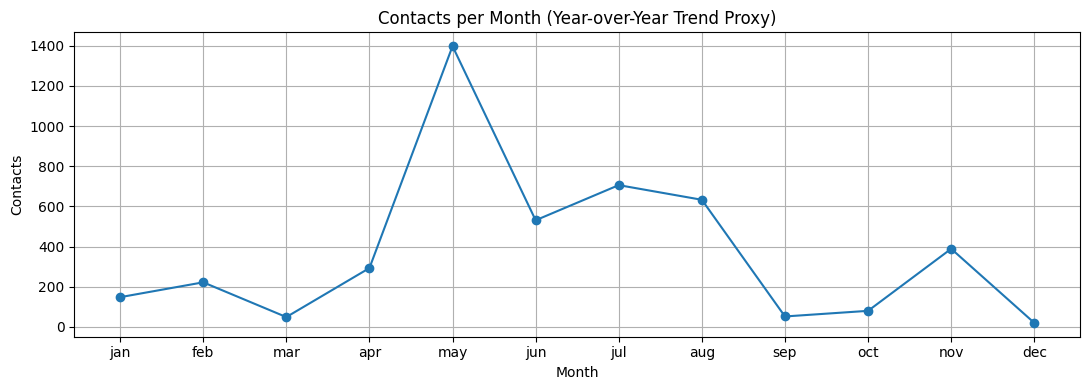

In [ ]:
# Define month order for proper chronological plotting
month_sequence = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

# Group data by month and align with defined order
monthly_trend = df.groupby('month').size().reindex(month_sequence)

# Plot the trend
plt.figure(figsize=(11, 4))
plt.plot(
    monthly_trend.index,
    monthly_trend.values,
    marker='o'
)

plt.title('Contacts per Month (Year-over-Year Trend Proxy)')
plt.xlabel('Month')
plt.ylabel('Contacts')

plt.grid(True)
plt.tight_layout()
plt.savefig('hive_trend_analysis.png', dpi=150)
plt.show()

## Q8 – Anomaly Detection

In [ ]:
q="""SELECT education, ROUND(AVG(balance),2) AS avg_bal,
           ROUND(MIN(balance),0) AS min_bal, ROUND(MAX(balance),0) AS max_bal
    FROM client_info GROUP BY education ORDER BY avg_bal DESC"""
r=ps.sqldf(q,locals())
print(r.to_string(index=False))
print('\nAnomaly: "unknown" education shows distinct balance pattern compared to others.')

education  avg_bal  min_bal  max_bal
 tertiary  1775.42  -3313.0  42045.0
  unknown  1701.25   -715.0  21244.0
  primary  1411.54   -966.0  71188.0
secondary  1196.81  -2082.0  26452.0

Anomaly: "unknown" education shows distinct balance pattern compared to others.


## Q9 – Advanced Analysis

In [ ]:
# poutcome impact on subscription
q="""
SELECT poutcome, COUNT(*) AS total,
       SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) AS subscribed,
       ROUND(SUM(CASE WHEN y='yes' THEN 1.0 ELSE 0 END)*100/COUNT(*),2) AS sub_rate
FROM client_info GROUP BY poutcome ORDER BY sub_rate DESC
"""
print('Impact of previous campaign outcome:')
ps.sqldf(q,locals())

Impact of previous campaign outcome:


,poutcome,total,subscribed,sub_rate
0,success,129,83,64.34
1,other,197,38,19.29
2,failure,490,63,12.86
3,unknown,3705,337,9.10


In [ ]:
# Avg duration: subscribed vs not
q="SELECT y AS subscribed, ROUND(AVG(duration),2) AS avg_duration FROM client_info GROUP BY y"
ps.sqldf(q,locals())

,subscribed,avg_duration
0,no,226.35
1,yes,552.74
